## 1. 실행 준비


In [2]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("torch") is None:
    raise ImportError("현재 커널에 PyTorch가 없습니다. 이 환경에서 python -m pip install torch 실행 후 커널을 재시작하세요.")

packages = ["sentencepiece", "numpy", "matplotlib", "pandas", "tqdm"]
missing = [name for name in packages if importlib.util.find_spec(name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import os
import re
import math
import json
import random
import hashlib
import shutil
import tarfile
import tempfile
import unicodedata
import urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import sentencepiece as spm
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from tqdm.auto import tqdm
from IPython.display import display

print("Python:", sys.version.split()[0], "| PyTorch:", torch.__version__)
print("SentencePiece:", spm.__version__)

Python: 3.12.9 | PyTorch: 2.13.0
SentencePiece: 0.2.2


/Users/yongza/300억/PRI_AI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. 직접 조절하는 설정


In [3]:
# ★ 자주 바꾸는 항목
RUN_NAME = "local_v2"        # 새 실험마다 새 이름: baseline_v2, dropout_03 등
LOCAL_WORK_ROOT = "/Users/yongza/uk0.01/beRich/transformer_local"  # CWD와 무관한 로컬 전용 절대 경로
DEVICE = "auto"                 # auto / cuda / mps / cpu
RUN_TRAINING = True              # 이미 학습했다면 False로 바꾸고 번역·평가만 실행
RESUME_TRAINING = True           # 같은 실험의 latest.pt가 있으면 이어서 학습
EPOCHS = 20                     # 추가 횟수가 아니라 '총 목표 횟수'
BATCH_SIZE = 64                 # 메모리 부족 시 새 RUN_NAME에서 16으로 낮추기
MAX_PAIRS = None                # None: 전체. 3000: 작은 실행 확인 실험

# ★ 모델·데이터 실험 항목: 변경 시 RUN_NAME도 변경
SRC_VOCAB_SIZE = 20000
TGT_VOCAB_SIZE = 20000
MAX_LEN = 50                    # 영어는 BOS/EOS까지 포함. 과제 제출은 50 유지
N_LAYERS = 2                    # 과제의 2층 조건 유지
D_MODEL = 512                   # 임베딩 차원. 256 → 512 실험 가능
N_HEADS = 8                     # D_MODEL이 N_HEADS로 나누어떨어져야 함
D_FF = 2048                     # FFN 중간 차원. 보통 이 실습에서는 D_MODEL의 4배
DROPOUT = 0.3                  
WARMUP_STEPS = 4000             # Noam 학습률이 증가하는 배치 수
LR_SCALE = 1.0                  # Noam 학습률 전체 배율
CLIP_NORM = 1.0                 # 기울기 폭주 방지
# 조기 종료 설정
EARLY_STOPPING = True
EARLY_STOP_PATIENCE = 3       # 의미 있는 개선이 3회 연속 없으면 종료
EARLY_STOP_MIN_DELTA = 0.001  # 기준 loss보다 0.001을 초과해 감소해야 개선

# 보통 유지하는 항목
SEED = 42
VAL_RATIO = 0.05
TEST_RATIO = 0.05
CHECKPOINT_EVERY = 100          # 완료 배치 100개마다 + 매 epoch 끝에 저장
ATTENTION_LAYER = -1            # -1: 마지막 층, 0: 첫 층
ATTENTION_HEAD = None           # None: head 평균, 0~7: 특정 head
TEST_EXAMPLES = 5               # 별도 테스트셋에서 출력할 문장 수
NO_REPEAT_NGRAM_SIZE = 3        # 생성 시 동일한 토큰 3개 묶음 금지. 0: 기존 greedy

assert re.fullmatch(r"[A-Za-z0-9_-]+", RUN_NAME), "실험 이름은 영문·숫자·밑줄·하이픈만 사용하세요."
assert DEVICE in {"auto", "cuda", "mps", "cpu"}
assert TEST_EXAMPLES >= 1
assert isinstance(NO_REPEAT_NGRAM_SIZE, int) and NO_REPEAT_NGRAM_SIZE >= 0
assert N_HEADS > 0 and D_MODEL > 0 and D_FF > 0
assert D_MODEL % N_HEADS == 0 and D_MODEL % 2 == 0
assert 3 <= MAX_LEN <= 50 and N_LAYERS == 2
assert BATCH_SIZE > 0 and EPOCHS >= 0 and CHECKPOINT_EVERY > 0
assert WARMUP_STEPS > 0 and LR_SCALE > 0 and CLIP_NORM > 0
assert 0 <= DROPOUT < 1 and 0 < VAL_RATIO + TEST_RATIO < 1
assert VAL_RATIO > 0 and TEST_RATIO > 0
assert MAX_PAIRS is None or MAX_PAIRS >= 100

## 3. 로컬 폴더와 실행 장치 연결


In [4]:
WORK_DIR = Path(LOCAL_WORK_ROOT).expanduser()
if not WORK_DIR.is_absolute():
    raise ValueError("LOCAL_WORK_ROOT에 로컬 폴더의 절대 경로를 넣으세요.")
WORK_DIR = WORK_DIR.resolve()
DATA_DIR = WORK_DIR / "data"
RUN_DIR = WORK_DIR / "runs" / RUN_NAME
RESULT_DIR = RUN_DIR / "results"
for folder in [DATA_DIR, RUN_DIR, RESULT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

if DEVICE == "auto":
    device = torch.device("cuda" if torch.cuda.is_available() else
                          "mps" if torch.backends.mps.is_available() else "cpu")
else:
    device = torch.device(DEVICE)
if device.type == "cuda" and not torch.cuda.is_available():
    raise RuntimeError("현재 커널에서 CUDA를 사용할 수 없습니다. DEVICE=auto 또는 설치 환경을 확인하세요.")
if device.type == "mps" and not torch.backends.mps.is_available():
    raise RuntimeError("MPS를 사용할 수 없습니다. macOS/PyTorch/커널 환경을 확인하세요.")
if device.type == "cpu":
    print("주의: CPU 실행입니다. 전체 학습보다 작은 실행 확인에 적합합니다.")

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)
    elif device.type == "mps":
        torch.mps.manual_seed(seed)

seed_everything(SEED)
print("실행 장치:", device)
print("원본 데이터:", DATA_DIR)
print("실험 저장:", RUN_DIR)

# 한글 Attention 라벨용 폰트. 폰트 설치 실패는 모델 학습 실패와 별개입니다.
font_paths = [Path("/System/Library/Fonts/AppleSDGothicNeo.ttc"),
              Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")]
for font_path in font_paths:
    if font_path.exists():
        fm.fontManager.addfont(str(font_path))
        plt.rcParams["font.family"] = fm.FontProperties(fname=str(font_path)).get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

실행 장치: mps
원본 데이터: /Users/yongza/uk0.01/beRich/transformer_local/data
실험 저장: /Users/yongza/uk0.01/beRich/transformer_local/runs/local_v2


### 저장 보조 함수
완성된 임시 파일로 교체해 저장 중 중단될 때 기존 파일을 바로 훼손하지 않게 합니다.
로컬 저장 공간이 부족하거나 쓰기에 실패하면 오류를 표시합니다. 같은 실험에는 한 커널만 저장해야 합니다.

In [5]:
def atomic_save(obj, path):
    path = Path(path)
    temporary = path.with_name(path.name + ".tmp")
    try:
        torch.save(obj, temporary)
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)


def write_json(obj, path):
    temporary = Path(str(path) + ".tmp")
    temporary.write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")
    os.replace(temporary, path)


def file_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

## 4. 데이터 전처리·SentencePiece·데이터셋


In [6]:
DATA_URL = "https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz"
RAW_NAMES = ["korean-english-park.train.ko", "korean-english-park.train.en"]


def prepare_parallel_data():
    missing = [name for name in RAW_NAMES if not (DATA_DIR / name).is_file() or (DATA_DIR / name).stat().st_size == 0]
    if not missing:
        print("로컬 폴더의 원본 데이터를 재사용합니다.")
        return
    archive_path = DATA_DIR / "korean-english-park.train.tar.gz"
    if not archive_path.exists():
        temporary = Path(str(archive_path) + ".part")
        print("원본 데이터를 다운로드합니다.")
        try:
            with urllib.request.urlopen(DATA_URL, timeout=120) as source, temporary.open("wb") as target:
                shutil.copyfileobj(source, target)
            with tarfile.open(temporary, "r:gz") as archive:
                available = {Path(m.name).name for m in archive.getmembers() if m.isfile()}
                if not set(RAW_NAMES).issubset(available):
                    raise ValueError("압축파일에 필요한 언어 파일이 없습니다.")
            os.replace(temporary, archive_path)
        finally:
            temporary.unlink(missing_ok=True)
    with tarfile.open(archive_path, "r:gz") as archive:
        members = {Path(m.name).name: m for m in archive.getmembers() if m.isfile()}
        for name in missing:
            temporary = DATA_DIR / (name + ".tmp")
            with archive.extractfile(members[name]) as source, temporary.open("wb") as target:
                shutil.copyfileobj(source, target)
            os.replace(temporary, DATA_DIR / name)

prepare_parallel_data()
RAW_HASHES = {name: file_hash(DATA_DIR / name) for name in RAW_NAMES}

로컬 폴더의 원본 데이터를 재사용합니다.


### 4-2. 문장 쌍 유지·중복 제거·데이터 분리
`set`에는 한국어만 따로, 영어만 따로 넣지 않고 **(한국어, 영어) 쌍**을 넣습니다.  
정제 후 새로 같아진 쌍도 제거합니다. 교재 조건대로 숫자·따옴표 등은 제거하며 `?.!,`는 남깁니다.


In [7]:
def preprocess_sentence(sentence):
    sentence = unicodedata.normalize("NFC", sentence).lower()
    sentence = re.sub(r"[^a-z가-힣?.!,]+", " ", sentence)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    return re.sub(r"\s+", " ", sentence).strip()


def clean_and_split():
    korean = (DATA_DIR / RAW_NAMES[0]).read_text(encoding="utf-8").splitlines()
    english = (DATA_DIR / RAW_NAMES[1]).read_text(encoding="utf-8").splitlines()
    if len(korean) != len(english):
        raise ValueError("한국어/영어 줄 수가 다릅니다. 두 파일을 같은 원본에서 복원하세요.")
    raw_seen, clean_seen = set(), set()
    cleaned_corpus = []
    for ko, en in zip(korean, english):
        if (ko, en) in raw_seen:
            continue
        raw_seen.add((ko, en))
        ko, en = preprocess_sentence(ko), preprocess_sentence(en)
        # 빈 문장이나 문장부호만 남은 문장은 학습하지 않습니다.
        if not re.search(r"[a-z가-힣]", ko) or not re.search(r"[a-z가-힣]", en):
            continue
        if (ko, en) not in clean_seen:
            clean_seen.add((ko, en))
            cleaned_corpus.append((ko, en))
    stats = {"raw_pairs": len(korean), "raw_unique_pairs": len(raw_seen),
             "clean_pairs": len(cleaned_corpus)}
    random.Random(SEED).shuffle(cleaned_corpus)
    if MAX_PAIRS is not None:
        cleaned_corpus = cleaned_corpus[:MAX_PAIRS]
    sources = list(dict.fromkeys(ko for ko, en in cleaned_corpus))
    random.Random(SEED).shuffle(sources)
    n_val = max(1, int(len(sources) * VAL_RATIO))
    n_test = max(1, int(len(sources) * TEST_RATIO))
    if len(sources) <= n_val + n_test:
        raise ValueError("분리할 데이터가 부족합니다.")
    val_sources = set(sources[:n_val])
    test_sources = set(sources[n_val:n_val + n_test])
    splits = {"train": [], "val": [], "test": []}
    for pair in cleaned_corpus:
        name = "val" if pair[0] in val_sources else "test" if pair[0] in test_sources else "train"
        splits[name].append(pair)
    stats["selected_pairs"] = len(cleaned_corpus)
    return splits, stats

print(preprocess_sentence("  Obama, 대통령! 123  "))

obama , 대통령 !


### 4-3. 토크나이저와 텐서 준비·재사용


In [8]:
DATA_CONFIG = {"version": 2, "raw_hashes": RAW_HASHES, "seed": SEED,
               "max_pairs": MAX_PAIRS, "max_len": MAX_LEN,
               "src_vocab": SRC_VOCAB_SIZE, "tgt_vocab": TGT_VOCAB_SIZE,
               "val_ratio": VAL_RATIO, "test_ratio": TEST_RATIO,
               "sentencepiece_version": spm.__version__}


def generate_tokenizer(corpus, vocab_size=20000, lang="ko"):
    # 임시 로컬 폴더에서 학습한 완성 파일만 RUN_DIR로 복사합니다.
    with tempfile.TemporaryDirectory() as temporary:
        prefix = Path(temporary) / lang
        corpus_path = Path(temporary) / "corpus.txt"
        corpus_path.write_text("\n".join(corpus) + "\n", encoding="utf-8")
        spm.SentencePieceTrainer.train(
            input=str(corpus_path), model_prefix=str(prefix), vocab_size=vocab_size,
            model_type="unigram", character_coverage=1.0,
            pad_id=0, bos_id=1, eos_id=2, unk_id=3,
            hard_vocab_limit=False, shuffle_input_sentence=False, num_threads=1,
            minloglevel=1)
        for suffix in [".model", ".vocab"]:
            target = RUN_DIR / f"{lang}_spm{suffix}"
            staged = Path(str(target) + ".tmp")
            shutil.copyfile(str(prefix) + suffix, staged)
            os.replace(staged, target)
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(str(RUN_DIR / f"{lang}_spm.model"))
    return tokenizer


def encode_pairs(pairs, ko_tokenizer, en_tokenizer):
    src_corpus, tgt_corpus, kept_pairs = [], [], []
    for ko, en in pairs:
        src_ids = ko_tokenizer.encode(ko, out_type=int)
        tgt_ids = en_tokenizer.encode(en, out_type=int, add_bos=True, add_eos=True)
        if 1 <= len(src_ids) <= MAX_LEN and 3 <= len(tgt_ids) <= MAX_LEN:
            src_corpus.append(torch.tensor(src_ids, dtype=torch.long))
            tgt_corpus.append(torch.tensor(tgt_ids, dtype=torch.long))
            kept_pairs.append((ko, en))
    if not kept_pairs:
        raise ValueError("길이 제한을 통과한 문장이 없습니다. 데이터 크기·단어장 설정을 확인하세요.")
    return {"src": pad_sequence(src_corpus, batch_first=True, padding_value=0),
            "tgt": pad_sequence(tgt_corpus, batch_first=True, padding_value=0),
            "pairs": kept_pairs}


def prepare_dataset():
    meta_path = RUN_DIR / "data_meta.json"
    dataset_path = RUN_DIR / "dataset.pt"
    if meta_path.exists():
        meta = json.loads(meta_path.read_text(encoding="utf-8"))
        if meta["config"] != DATA_CONFIG:
            raise ValueError("데이터 설정이 이전 실행과 다릅니다. RUN_NAME을 새 이름으로 바꾸세요.")
        for name, expected_hash in meta["hashes"].items():
            if not (RUN_DIR / name).exists() or file_hash(RUN_DIR / name) != expected_hash:
                raise ValueError(f"저장 파일이 없거나 변경되었습니다: {name}. 로컬 실험 폴더의 파일을 확인하세요.")
        ko_tokenizer = spm.SentencePieceProcessor(model_file=str(RUN_DIR / "ko_spm.model"))
        en_tokenizer = spm.SentencePieceProcessor(model_file=str(RUN_DIR / "en_spm.model"))
        dataset = torch.load(dataset_path, map_location="cpu", weights_only=True)
        print("로컬 토크나이저와 데이터셋을 재사용합니다.")
        return dataset, ko_tokenizer, en_tokenizer, meta
    if (RUN_DIR / "latest.pt").exists() or (RUN_DIR / "best.pt").exists():
        raise RuntimeError("체크포인트는 있는데 데이터 기록이 없습니다. 해당 실험의 데이터 기록과 토크나이저를 함께 복원하세요.")
    splits, stats = clean_and_split()
    kor_corpus = [ko for ko, en in splits["train"]]
    eng_corpus = [en for ko, en in splits["train"]]
    ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
    en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
    dataset = {}
    for name, pairs in splits.items():
        dataset[name] = encode_pairs(pairs, ko_tokenizer, en_tokenizer)
        stats[name + "_before_length"] = len(pairs)
        stats[name + "_pairs"] = len(dataset[name]["pairs"])
    atomic_save(dataset, dataset_path)
    hashes = {name: file_hash(RUN_DIR / name) for name in ["dataset.pt", "ko_spm.model", "en_spm.model"]}
    meta = {"config": DATA_CONFIG, "stats": stats, "hashes": hashes}
    write_json(meta, meta_path)  # 마지막에 완료 기록을 씁니다.
    return dataset, ko_tokenizer, en_tokenizer, meta

dataset, ko_tokenizer, en_tokenizer, data_meta = prepare_dataset()
PAD, BOS, EOS, UNK = 0, 1, 2, 3
for tokenizer in [ko_tokenizer, en_tokenizer]:
    assert [tokenizer.pad_id(), tokenizer.bos_id(), tokenizer.eos_id(), tokenizer.unk_id()] == [PAD, BOS, EOS, UNK]
enc_train, dec_train = dataset["train"]["src"], dataset["train"]["tgt"]
display(pd.DataFrame([data_meta["stats"]]).T.rename(columns={0: "문장 쌍 수"}))
print("실제 단어장 크기:", ko_tokenizer.vocab_size(), en_tokenizer.vocab_size())
print("enc_train / dec_train:", enc_train.shape, dec_train.shape)
print("한국어 조각:", ko_tokenizer.encode(dataset["train"]["pairs"][0][0], out_type=str))
print("영어 ID(BOS=1, EOS=2):", dec_train[0].tolist())

# 학습·검증·테스트에 같은 한국어 문장이 들어가지 않았는지 검사
source_sets = {name: {ko for ko, en in part["pairs"]} for name, part in dataset.items()}
assert not source_sets["train"] & source_sets["val"]
assert not source_sets["train"] & source_sets["test"]
assert not source_sets["val"] & source_sets["test"]
for part in dataset.values():
    assert part["src"].shape[1] <= MAX_LEN and part["tgt"].shape[1] <= MAX_LEN
    assert torch.all(part["tgt"][:, 0] == BOS)
    assert torch.all((part["tgt"] == EOS).sum(dim=1) == 1)
print("데이터·특수 토큰·분리 검사 통과")

로컬 토크나이저와 데이터셋을 재사용합니다.


,문장 쌍 수
raw_pairs,94123
raw_unique_pairs,78968
clean_pairs,78802
selected_pairs,78802
train_before_length,70800
train_pairs,67722
val_before_length,4069
val_pairs,3889
test_before_length,3933
test_pairs,3757


실제 단어장 크기: 20000 20000
enc_train / dec_train: torch.Size([67722, 50]) torch.Size([67722, 50])
한국어 조각: ['▁버락', '▁오바마', '▁대통령은', '▁관타나모', '만', '의', '▁해군', '기', '지', '▁수용소', '를', '▁년', '▁안에', '▁폐쇄', '한다는', '▁대통령', '령', '에', '▁서명', '을', '▁할', '▁것으로', '▁예상되고', '▁있습니다', '▁.']
영어 ID(BOS=1, EOS=2): [1, 57, 431, 113, 17, 218, 7, 938, 30, 840, 617, 315, 6, 2601, 4, 104, 708, 22, 4540, 1784, 548, 9, 49, 5, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
데이터·특수 토큰·분리 검사 통과


## 5. Transformer 직접 구현


### 5-1. Padding mask·Causal mask


In [9]:
def generate_padding_mask(seq):
    return (seq == PAD)[:, None, None, :]  # [batch, 1, 1, key_length]


def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)
    # 마스크를 입력과 같은 장치에서 만들어 CPU/CUDA/MPS 혼용을 피합니다.
    future_mask = torch.triu(torch.ones(tgt.size(1), tgt.size(1),
                                       dtype=torch.bool, device=tgt.device), diagonal=1)
    dec_mask = generate_padding_mask(tgt) | future_mask
    return enc_mask, enc_mask, dec_mask


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.depth = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        # [B, L, D] → [B, H, L, D/H]
        return x.reshape(x.size(0), x.size(1), self.num_heads, self.depth).transpose(1, 2)

    def forward(self, query, key, value, mask=None):
        q = self.split_heads(self.W_q(query))
        k = self.split_heads(self.W_k(key))
        v = self.split_heads(self.W_v(value))
        # Q·K로 관련성을 계산하고, softmax로 각 행의 합을 1로 만듭니다.
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.depth)
        if mask is not None:
            scores = scores.masked_fill(mask, -1e9)
        attention = torch.softmax(scores, dim=-1)
        out = torch.matmul(attention, v)
        out = out.transpose(1, 2).contiguous().reshape(query.size(0), query.size(1), -1)
        return self.linear(out), attention


class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(torch.relu(self.linear1(x)))

### 5-2. EncoderLayer·DecoderLayer
 **정규화 → 계산 → 잔차 연결(Pre-LN)** 순서

In [10]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        normalized = self.norm1(x)
        out, attention = self.attention(normalized, normalized, normalized, mask)
        x = x + self.dropout(out)
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x, attention


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, n_heads)
        self.cross_attention = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, memory, src_mask, tgt_mask):
        normalized = self.norm1(x)
        out, self_attention = self.self_attention(normalized, normalized, normalized, tgt_mask)
        x = x + self.dropout(out)
        # Query는 영어 쪽, Key·Value는 Encoder의 한국어 표현입니다.
        out, cross_attention = self.cross_attention(self.norm2(x), memory, memory, src_mask)
        x = x + self.dropout(out)
        x = x + self.dropout(self.ffn(self.norm3(x)))
        return x, self_attention, cross_attention


class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask):
        attentions = []
        for layer in self.layers:
            x, attention = layer(x, mask)
            attentions.append(attention.detach())
        return self.norm(x), attentions


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, memory, src_mask, tgt_mask):
        self_attentions, cross_attentions = [], []
        for layer in self.layers:
            x, self_attention, cross_attention = layer(x, memory, src_mask, tgt_mask)
            self_attentions.append(self_attention.detach())
            cross_attentions.append(cross_attention.detach())
        return self.norm(x), self_attentions, cross_attentions

### 5-3. Embedding + Positional Encoding + 2층 조립
한·영 토크나이저는 서로 다르므로 입력 임베딩도 별개입니다. **영어 임베딩과 영어 출력층만 가중치를 공유**합니다.


In [11]:
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, src_vocab_size, tgt_vocab_size, pos_len, dropout):
        super().__init__()
        self.scale = math.sqrt(d_model)  # Python 숫자여서 특정 장치에 묶이지 않습니다.
        self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD)
        nn.init.normal_(self.enc_emb.weight, std=d_model ** -0.5)
        nn.init.normal_(self.dec_emb.weight, std=d_model ** -0.5)
        with torch.no_grad():
            self.enc_emb.weight[PAD].zero_()
            self.dec_emb.weight[PAD].zero_()
        position = torch.arange(pos_len, dtype=torch.float32).unsqueeze(1)
        frequency = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        positional = torch.zeros(pos_len, d_model, dtype=torch.float32)
        positional[:, 0::2] = torch.sin(position * frequency)
        positional[:, 1::2] = torch.cos(position * frequency)
        self.register_buffer("pos_encoding", positional)
        self.dropout = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.fc.weight = self.dec_emb.weight

    def embedding(self, tokens, layer):
        if tokens.size(1) > self.pos_encoding.size(0):
            raise ValueError("입력 토큰 길이가 위치 정보 범위를 넘었습니다.")
        out = layer(tokens) * self.scale + self.pos_encoding[:tokens.size(1)]
        return self.dropout(out)

    def encode(self, src):
        return self.encoder(self.embedding(src, self.enc_emb), generate_padding_mask(src))

    def decode(self, src, tgt, memory):
        _, src_mask, tgt_mask = generate_masks(src, tgt)
        out, self_attn, cross_attn = self.decoder(self.embedding(tgt, self.dec_emb), memory, src_mask, tgt_mask)
        return self.fc(out), self_attn, cross_attn

    def forward(self, src, tgt):
        memory, enc_attn = self.encode(src)
        logits, self_attn, cross_attn = self.decode(src, tgt, memory)
        return logits, enc_attn, self_attn, cross_attn

MODEL_CONFIG = {"n_layers": N_LAYERS, "d_model": D_MODEL, "n_heads": N_HEADS, "d_ff": D_FF,
                "src_vocab_size": ko_tokenizer.vocab_size(), "tgt_vocab_size": en_tokenizer.vocab_size(),
                "pos_len": MAX_LEN, "dropout": DROPOUT}

## 6. 학습 도구와 기본 검사
**Teacher forcing:** 영어 `[BOS, i, like, coffee, EOS]`에서 입력은 `[BOS, i, like, coffee]`, 정답은 `[i, like, coffee, EOS]`입니다.
`CrossEntropyLoss(ignore_index=0)`는 PAD를 제외합니다. epoch loss도 **실제 정답 토큰 수로 가중 평균**합니다.
Noam 스케줄은 매 배치 갱신하며, 첫 optimizer 업데이트에는 수식의 step=1 학습률이 적용됩니다.

In [ ]:
def noam_schedule(d_model, warmup_steps, scale=1.0):
    def lr_lambda(step):
        step = step + 1  # LambdaLR의 초기 step=0을 수식의 step=1로 대응
        return scale * d_model ** -0.5 * min(step ** -0.5, step * warmup_steps ** -1.5)
    return lr_lambda


def build_training_objects():
    seed_everything(SEED)
    model = Transformer(**MODEL_CONFIG).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9, foreach=False)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, noam_schedule(D_MODEL, WARMUP_STEPS, LR_SCALE))
    return model, optimizer, scheduler

loss_object = nn.CrossEntropyLoss(ignore_index=PAD)


def train_step(src, tgt, model, optimizer, scheduler):
    model.train()
    src, tgt = src.to(device), tgt.to(device)
    dec_in, gold = tgt[:, :-1], tgt[:, 1:]
    optimizer.zero_grad(set_to_none=True)
    logits, _, _, _ = model(src, dec_in)
    loss = loss_object(logits.reshape(-1, logits.size(-1)), gold.reshape(-1))
    if not torch.isfinite(loss).item():
        raise FloatingPointError("loss가 유한하지 않습니다. 마지막 체크포인트를 보존합니다.")
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM, error_if_nonfinite=True)
    optimizer.step()
    scheduler.step()
    token_count = int((gold != PAD).sum().item())
    return loss.item() * token_count, token_count


@torch.no_grad()
def evaluate_loss(model, split):
    model.eval()
    loss_sum, token_sum = 0.0, 0
    for start in range(0, len(split["src"]), BATCH_SIZE):
        src = split["src"][start:start + BATCH_SIZE].to(device)
        tgt = split["tgt"][start:start + BATCH_SIZE].to(device)
        gold = tgt[:, 1:]
        logits, _, _, _ = model(src, tgt[:, :-1])
        loss = loss_object(logits.reshape(-1, logits.size(-1)), gold.reshape(-1))
        count = int((gold != PAD).sum().item())
        loss_sum += loss.item() * count
        token_sum += count
    result = loss_sum / token_sum
    if not math.isfinite(result):
        raise FloatingPointError("평가 loss가 유한하지 않습니다.")
    return result

# 저장 전 간단한 순전파·마스크 검사. 이 모델은 검사 후 버립니다.
check_model, _, _ = build_training_objects()
check_model.eval()
with torch.no_grad():
    sample_src = torch.tensor([[4, 5, PAD]], device=device)
    sample_tgt = torch.tensor([[BOS, 4, 5]], device=device)
    sample_logits, enc_attn, dec_attn, cross_attn = check_model(sample_src, sample_tgt)
    assert torch.isfinite(sample_logits).all().item()
    assert sample_logits.shape == (1, 3, en_tokenizer.vocab_size())
    assert enc_attn[-1][..., -1].abs().max().item() < 1e-6
    assert dec_attn[-1].triu(diagonal=1).abs().max().item() < 1e-6
    assert cross_attn[-1][..., -1].abs().max().item() < 1e-6
print("모델 순전파·PAD·미래 토큰 마스크 검사 통과")
print("파라미터 수:", f"{sum(p.numel() for p in check_model.parameters()):,}")
del check_model, sample_logits, enc_attn, dec_attn, cross_attn, _

## 7. 번역 함수와 체크포인트
### 7-1. 한 토큰씩 영어 생성
추론에서는 정답 영어를 주지 않고 BOS부터 시작합니다. 매번 점수가 가장 높은 토큰을 고르는 **greedy decoding**입니다.
BOS/PAD 재생성을 막고 아래 반복 제한 규칙을 적용합니다. UNK는 숨기지 않습니다. EOS가 나오거나 최대 길이에 도달하면 종료합니다.
한국어 입력이 50토큰을 넘으면 자르지 않고 오류를 알려줍니다.

### 반복 구절을 막는 작은 생성 규칙
`NO_REPEAT_NGRAM_SIZE=3`은 이미 출력한 **SentencePiece 토큰 3개 묶음**을 다시 완성하는 다음 토큰의 점수를 `-inf`로 바꿔 선택에서 제외합니다. 나머지 후보 중 가장 점수가 높은 토큰을 고릅니다. 예를 들어 `the / city / of`가 각각 한 토큰이면 같은 묶음을 다시 완성하는 `of`가 차단됩니다. 실제 단어는 여러 조각으로 나뉠 수 있습니다.

이는 [Hugging Face의 NoRepeatNGramLogitsProcessor](https://huggingface.co/docs/transformers/main/en/internal/generation_utils#transformers.NoRepeatNGramLogitsProcessor)와 같은 원리의 작은 직접 구현입니다. 별도 모델이나 Transformers 패키지를 추가하지 않습니다. EOS(문장 끝) 후보는 유지합니다.



In [ ]:
EXAMPLES = ["오바마는 대통령이다.", "시민들은 도시 속에 산다.",
            "커피는 필요 없다.", "일곱 명의 사망자가 발생했다."]


def piece_labels(tokenizer, ids):
    return [tokenizer.id_to_piece(i).replace("▁", "_") for i in ids]


def banned_next_tokens(generated, n):
    # 현재 끝부분에 이어 붙이면 기존 n-gram이 재등장하는 후보를 찾습니다.
    if n == 0 or len(generated) + 1 < n:
        return []
    prefix = generated[-(n - 1):] if n > 1 else []
    return list({generated[i + n - 1]
                 for i in range(len(generated) - n + 1)
                 if generated[i:i + n - 1] == prefix and generated[i + n - 1] != EOS})


@torch.no_grad()
def evaluate(sentence, model, no_repeat_ngram_size=None):
    if no_repeat_ngram_size is None:
        no_repeat_ngram_size = NO_REPEAT_NGRAM_SIZE
    if not isinstance(no_repeat_ngram_size, int) or no_repeat_ngram_size < 0:
        raise ValueError("no_repeat_ngram_size는 0 이상의 정수여야 합니다.")
    model.eval()
    cleaned = preprocess_sentence(sentence)
    if not re.search(r"[a-z가-힣]", cleaned):
        raise ValueError("정제 후 글자가 남지 않았습니다.")
    src_ids = ko_tokenizer.encode(cleaned, out_type=int)
    if not 1 <= len(src_ids) <= MAX_LEN:
        raise ValueError(f"한국어 입력은 1~{MAX_LEN}토큰이어야 합니다. 현재 {len(src_ids)}토큰입니다.")
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    memory, enc_attn = model.encode(src)  # 한국어는 한 번만 인코딩
    output = torch.tensor([[BOS]], dtype=torch.long, device=device)
    generated = []
    cross_rows = [[] for _ in range(N_LAYERS)]
    ended = False
    for _ in range(MAX_LEN - 1):
        input_ids = output[0].tolist()  # 이번 예측에 실제로 사용한 디코더 입력
        logits, self_attn, cross_attn = model.decode(src, output, memory)
        scores = logits[0, -1].clone()
        if not torch.isfinite(scores).all().item():
            raise FloatingPointError("생성 점수에 NaN/inf가 있습니다. 모델과 학습 상태를 확인하세요.")
        scores[PAD] = scores[BOS] = -float("inf")
        banned = banned_next_tokens(generated, no_repeat_ngram_size)
        if banned:
            scores[banned] = -float("inf")
        next_id = int(scores.argmax().item())
        generated.append(next_id)
        # '이번에 생성한 토큰'을 예측할 때 사용한 마지막 query 행을 저장
        for layer in range(N_LAYERS):
            cross_rows[layer].append(cross_attn[layer][0, :, -1:, :].cpu())
        if next_id == EOS:
            ended = True
            break
        output = torch.cat([output, torch.tensor([[next_id]], device=device)], dim=1)
    text_ids = [i for i in generated if i != EOS]
    return {"text": en_tokenizer.decode(text_ids), "ended_with_eos": ended,
            "no_repeat_ngram_size": no_repeat_ngram_size,
            "src_labels": piece_labels(ko_tokenizer, src_ids),
            "input_labels": piece_labels(en_tokenizer, input_ids),
            "output_labels": piece_labels(en_tokenizer, generated),
            "encoder": [a[0].cpu() for a in enc_attn],
            "decoder": [a[0].cpu() for a in self_attn],
            "cross": [torch.cat(rows, dim=1) for rows in cross_rows]}


def translate(sentence, model, no_repeat_ngram_size=None):
    result = evaluate(sentence, model, no_repeat_ngram_size)
    print("한국어:", sentence)
    print("영어:", result["text"])
    if not result["ended_with_eos"]:
        print("주의: EOS 없이 최대 생성 길이에 도달했습니다.")
    return result

### 7-2. 체크포인트 저장·복원
`latest.pt`는 매 100배치 및 epoch 끝에 저장합니다. 모델뿐 아니라 Adam 내부 상태, 학습률, 다음 배치 위치, 누적 loss, 난수 상태와 기록을 함께 보관합니다.
같은 epoch의 문장 순서는 `SEED + epoch`으로 다시 만들어 이미 완료한 배치를 건너뜁니다.

중단되면 **마지막 완성 체크포인트 뒤의 배치는 다시 계산**합니다. 

In [ ]:
TRAIN_SIGNATURE = {"code_version": 2, "model": MODEL_CONFIG, "data": data_meta["hashes"],
                   "batch_size": BATCH_SIZE, "seed": SEED, "warmup": WARMUP_STEPS,
                   "lr_scale": LR_SCALE, "clip_norm": CLIP_NORM}
LATEST_PATH = RUN_DIR / "latest.pt"
BEST_PATH = RUN_DIR / "best.pt"
# 설정 셀만 바꾸고 학습 셀로 건너뛴 실수를 잡습니다.
PREPARED_SETTINGS = {name: globals()[name] for name in [
    "RUN_NAME", "LOCAL_WORK_ROOT", "DEVICE", "BATCH_SIZE", "MAX_PAIRS",
    "SRC_VOCAB_SIZE", "TGT_VOCAB_SIZE", "MAX_LEN", "N_LAYERS", "D_MODEL",
    "N_HEADS", "D_FF", "DROPOUT", "WARMUP_STEPS", "LR_SCALE", "CLIP_NORM",
    "SEED", "VAL_RATIO", "TEST_RATIO"]}


def cpu_state(value):
    # 체크포인트 안의 텐서를 CPU로 옮겨 다른 장치에서도 읽기 쉽게 합니다.
    if isinstance(value, torch.Tensor):
        return value.detach().cpu()
    if isinstance(value, dict):
        return {key: cpu_state(item) for key, item in value.items()}
    if isinstance(value, list):
        return [cpu_state(item) for item in value]
    if isinstance(value, tuple):
        return tuple(cpu_state(item) for item in value)
    return value


def save_checkpoint(model, optimizer, scheduler, progress):
    state = {"signature": TRAIN_SIGNATURE, "model": cpu_state(model.state_dict()),
             "optimizer": cpu_state(optimizer.state_dict()), "scheduler": scheduler.state_dict(),
             "progress": progress, "python_rng": random.getstate(), "torch_rng": torch.get_rng_state(),
             "device": device.type, "torch_version": str(torch.__version__)}
    if device.type == "cuda":
        state["gpu_rng"] = torch.cuda.get_rng_state()
    elif device.type == "mps":
        state["gpu_rng"] = torch.mps.get_rng_state()
    atomic_save(state, LATEST_PATH)


def load_checkpoint(model, optimizer, scheduler):
    state = torch.load(LATEST_PATH, map_location="cpu", weights_only=True)
    if state["signature"] != TRAIN_SIGNATURE:
        raise ValueError("체크포인트와 현재 설정이 다릅니다. 새 실험은 RUN_NAME을 바꾸세요.")
    model.load_state_dict(state["model"])
    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    # Adam의 누적값은 매개변수 장치로, step 카운터는 기본 CPU에 둡니다.
    for values in optimizer.state.values():
        for name in ["exp_avg", "exp_avg_sq"]:
            if name in values:
                values[name] = values[name].to(device)
    random.setstate(state["python_rng"])
    torch.set_rng_state(state["torch_rng"])
    if state["device"] == device.type:
        if device.type == "cuda":
            torch.cuda.set_rng_state(state["gpu_rng"])
        elif device.type == "mps":
            torch.mps.set_rng_state(state["gpu_rng"])
    else:
        print(f"장치 변경: {state['device']} → {device.type}. 수치·난수 결과가 같지는 않을 수 있습니다.")
    if state["torch_version"] != str(torch.__version__):
        print("주의: 저장 당시와 PyTorch 버전이 다릅니다.")
    return state["progress"]

### 7-3. 16회차 가중치 보존
`latest.pt`의 **16회차 완료 가중치**를 `epoch_016.pt`로 한 번 보존합니다. 추가 학습 전에 실행하세요.
이미 보존한 파일이 있으면 epoch(에포크)와 설정을 검사하고 재사용합니다. 16회차 파일이 없고 latest가 다른 회차라면 오류를 표시합니다.
`best.pt`는 검증 손실 최저 모델을 계속 보관합니다. 현재 기록에서는 13회차입니다.

Based-On: MLDL-03-02-C062@6259b7f7c54d · project_extension(프로젝트 확장).
예제의 state_dict(상태 사전) 저장 방식을 따르며, 여기서는 번역·어텐션 확인용 모델 가중치만 보관합니다. 학습 재개에는 optimizer(최적화기) 상태가 있는 `latest.pt`를 사용합니다.
같은 실험의 학습은 한 커널에서만 실행하세요.

In [ ]:
EPOCH16_PATH = RUN_DIR / "epoch_016.pt"


def preserve_epoch16():
    if not EPOCH16_PATH.exists():
        state = torch.load(LATEST_PATH, map_location="cpu", weights_only=True)
        saved = state["progress"]
        if (state["signature"] != TRAIN_SIGNATURE or saved["epoch"] != 16
                or saved["next_batch"] != 0):
            raise ValueError("16회차 완료 latest.pt가 필요합니다. 다른 회차를 16회차로 저장할 수 없습니다.")
        row = next(row for row in saved["history"] if row["epoch"] == 16)
        snapshot = {"signature": state["signature"], "model": state["model"],
                    "epoch": 16, "val_loss": row["val_loss"]}
        # 저장 실패·중단 시 완성 파일만 남기고, 기존 파일은 덮어쓰지 않습니다.
        with tempfile.TemporaryDirectory(dir=RUN_DIR) as temporary:
            temporary_path = Path(temporary) / "epoch_016.pt"
            torch.save(snapshot, temporary_path)
            try:
                os.link(temporary_path, EPOCH16_PATH)
            except FileExistsError:
                pass  # 먼저 완성된 파일을 아래에서 검사합니다.
        del state, snapshot
    state = torch.load(EPOCH16_PATH, map_location="cpu", weights_only=True)
    if state["signature"] != TRAIN_SIGNATURE or state["epoch"] != 16:
        raise ValueError("epoch_016.pt의 회차 또는 설정이 현재 실험과 다릅니다.")
    return state


saved_epoch16 = preserve_epoch16()
print(f"16회차 보존: {EPOCH16_PATH} | val={saved_epoch16['val_loss']:.4f}")
del saved_epoch16

16회차 보존: /Users/yongza/uk0.01/beRich/transformer_local/runs/local_v2/epoch_016.pt | val=4.1286


## 8.  학습 실행·이어 학습
처음은 그대로 실행합니다. 중단 후 같은 커널에서는 **아래 셀만 다시 실행**해도 저장 지점부터 재개합니다.
커널을 재시작했으면 같은 설정으로 위에서부터 실행합니다. 함수가 모델·optimizer를 새로 만든 뒤 체크포인트를 복원합니다.

`EPOCHS=10`을 마친 뒤 더 학습하려면 `EPOCHS=15`로 바꾸고 이 셀을 실행하면 됩니다.
`RESUME_TRAINING=False`로 기존 결과를 덮어쓰지 못하게 막습니다. 새 실험은 새 이름으로 시작합니다.

In [ ]:
def refresh_early_stop(progress, enabled=None):
    """저장된 epoch 기록으로 조기 종료 상태를 계산합니다. 예전 체크포인트도 지원합니다."""
    reference_loss = float("inf")
    wait = 0

    for row in progress["history"]:
        value = float(row["val_loss"])

        if not math.isfinite(value):
            raise ValueError("저장된 검증 loss에 NaN 또는 inf가 있습니다.")

        # 마지막으로 '의미 있게 개선'됐던 loss와 비교합니다.
        if value < reference_loss - EARLY_STOP_MIN_DELTA:
            reference_loss = value
            wait = 0
        else:
            wait += 1

    # 기존 save_checkpoint()가 progress 전체를 저장하므로 함께 보관됩니다.
    progress["early_stop"] = {
        "reference_loss": reference_loss,
        "wait": wait,
        "patience": EARLY_STOP_PATIENCE,
        "min_delta": EARLY_STOP_MIN_DELTA,
    }

    enabled = EARLY_STOPPING if enabled is None else enabled
    return enabled and wait >= EARLY_STOP_PATIENCE


def run_training(target_epochs=None, early_stopping=None):
    # 추가 실험에서만 목표 횟수와 종료 여부를 덮어씁니다. 기존 설정값은 유지합니다.
    target_epochs = EPOCHS if target_epochs is None else target_epochs
    early_stopping = EARLY_STOPPING if early_stopping is None else early_stopping
    if not isinstance(target_epochs, int) or target_epochs < 0:
        raise ValueError("target_epochs는 0 이상의 정수여야 합니다.")

    if not isinstance(EARLY_STOP_PATIENCE, int) or EARLY_STOP_PATIENCE < 1:
        raise ValueError("EARLY_STOP_PATIENCE는 1 이상의 정수여야 합니다.")

    if not math.isfinite(EARLY_STOP_MIN_DELTA) or EARLY_STOP_MIN_DELTA < 0:
        raise ValueError("EARLY_STOP_MIN_DELTA는 0 이상의 유한한 수여야 합니다.")

    changed = [
        name for name, value in PREPARED_SETTINGS.items()
        if globals()[name] != value
    ]

    if changed or RUN_DIR.name != RUN_NAME:
        raise ValueError(
            f"준비 이후 설정이 변경되었습니다: {changed}. 기존 실험 설정을 복원하세요."
        )

    if not RESUME_TRAINING and (LATEST_PATH.exists() or BEST_PATH.exists()):
        raise FileExistsError("기존 실험은 RESUME_TRAINING=True로 재개하세요.")

    # 모델과 학습 도구를 만든 뒤, 저장된 상태를 복원합니다.
    model, optimizer, scheduler = build_training_objects()

    progress = {
        "epoch": 0,
        "next_batch": 0,
        "loss_sum": 0.0,
        "token_sum": 0,
        "best_val": float("inf"),
        "history": [],
        "translations": [],
    }

    if RESUME_TRAINING and LATEST_PATH.exists():
        progress = load_checkpoint(model, optimizer, scheduler)
        print(
            f"재개: 완료 epoch={progress['epoch']}, "
            f"완료 배치={progress['next_batch']}"
        )
    elif BEST_PATH.exists():
        raise RuntimeError(
            "best.pt만 있고 latest.pt가 없습니다. 저장 경로를 확인하세요."
        )

    # ★ 기존 기록부터 판정합니다.
    # 이미 조기 종료 조건을 충족했다면 추가 배치를 돌리지 않습니다.
    should_stop = refresh_early_stop(progress, enabled=early_stopping)
    save_checkpoint(model, optimizer, scheduler, progress)

    write_json(
        {
            "run_name": RUN_NAME,
            "signature": TRAIN_SIGNATURE,
            "epochs_target": target_epochs,
            "device": str(device),
            "torch": str(torch.__version__),
            "early_stopping": early_stopping,
            "patience": EARLY_STOP_PATIENCE,
            "min_delta": EARLY_STOP_MIN_DELTA,
        },
        RUN_DIR / "run_config.json",
    )

    if should_stop:
        print(
            f"이미 조기 종료 조건 충족: "
            f"미개선 {progress['early_stop']['wait']}회. 추가 학습하지 않습니다."
        )

    n_batches = math.ceil(len(enc_train) / BATCH_SIZE)

    try:
        while progress["epoch"] < target_epochs and not should_stop:
            epoch = progress["epoch"]

            # 같은 epoch의 문장 순서를 복원합니다.
            generator = torch.Generator().manual_seed(SEED + epoch)
            order = torch.randperm(len(enc_train), generator=generator)
            start_batch = progress["next_batch"]

            bar = tqdm(
                range(start_batch, n_batches),
                initial=start_batch,
                total=n_batches,
                desc=f"Epoch {epoch + 1}/{target_epochs}",
            )

            for batch in bar:
                ids = order[batch * BATCH_SIZE:(batch + 1) * BATCH_SIZE]

                loss_sum, token_count = train_step(
                    enc_train[ids],
                    dec_train[ids],
                    model,
                    optimizer,
                    scheduler,
                )

                progress["loss_sum"] += loss_sum
                progress["token_sum"] += token_count
                progress["next_batch"] = batch + 1

                bar.set_postfix(
                    loss=f"{progress['loss_sum'] / progress['token_sum']:.4f}"
                )

                if (batch + 1) % CHECKPOINT_EVERY == 0:
                    save_checkpoint(model, optimizer, scheduler, progress)

            # 이번 epoch의 검증 손실 계산
            val_loss = evaluate_loss(model, dataset["val"])

            if not math.isfinite(val_loss):
                raise FloatingPointError(
                    "검증 loss가 NaN/inf입니다. 마지막 완성 체크포인트는 보존합니다."
                )

            train_loss = progress["loss_sum"] / progress["token_sum"]

            # 과제 예문 번역 기록
            for sentence in EXAMPLES:
                result = evaluate(sentence, model)

                progress["translations"].append(
                    {
                        "epoch": epoch + 1,
                        "korean": sentence,
                        "english": result["text"],
                        "eos": result["ended_with_eos"],
                    }
                )
                print(sentence, "→", result["text"])

            progress["history"].append(
                {
                    "epoch": epoch + 1,
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "next_lr": scheduler.get_last_lr()[0],
                }
            )

            # ★ 최적 모델 저장과 조기 종료 기준은 구분합니다.
            # best.pt는 아주 조금이라도 '실제 최저 loss'를 갱신하면 저장합니다.
            if val_loss < progress["best_val"]:
                progress["best_val"] = val_loss

                atomic_save(
                    {
                        "signature": TRAIN_SIGNATURE,
                        "model": cpu_state(model.state_dict()),
                        "epoch": epoch + 1,
                        "val_loss": val_loss,
                    },
                    BEST_PATH,
                )

            # ★ 조기 종료 여부를 판단합니다.
            should_stop = refresh_early_stop(progress, enabled=early_stopping)

            # 종료하더라도 방금 완료한 epoch와 기록부터 저장합니다.
            progress.update(
                epoch=epoch + 1,
                next_batch=0,
                loss_sum=0.0,
                token_sum=0,
            )
            save_checkpoint(model, optimizer, scheduler, progress)

            pd.DataFrame(progress["history"]).to_csv(
                RESULT_DIR / "history.csv",
                index=False,
                encoding="utf-8-sig",
            )
            pd.DataFrame(progress["translations"]).to_csv(
                RESULT_DIR / "epoch_translations.csv",
                index=False,
                encoding="utf-8-sig",
            )

            print(
                f"Epoch {epoch + 1}: "
                f"train={train_loss:.4f}, val={val_loss:.4f} | 저장 완료"
            )

            if early_stopping:
                print(
                    f"Early stopping: "
                    f"미개선 {progress['early_stop']['wait']}/"
                    f"{EARLY_STOP_PATIENCE}회"
                )

            if should_stop:
                print(
                    "조기 종료합니다. "
                    "최종 번역은 9번 평가 셀부터 실행하세요."
                )

    except KeyboardInterrupt:
        # 임의 중단 순간의 불완전한 업데이트는 저장하지 않습니다.
        print("수동 중단했습니다. 마지막 완성 체크포인트는 보존됩니다.")
        raise

    # 재개하자마자 종료된 경우에도 저장된 기록으로 CSV를 복구합니다.
    pd.DataFrame(progress["history"]).to_csv(
        RESULT_DIR / "history.csv",
        index=False,
        encoding="utf-8-sig",
    )
    pd.DataFrame(progress["translations"]).to_csv(
        RESULT_DIR / "epoch_translations.csv",
        index=False,
        encoding="utf-8-sig",
    )

    if progress["history"]:
        best_row = min(
            progress["history"],
            key=lambda row: row["val_loss"],
        )
        print(
            f"최저 검증 loss: "
            f"epoch {best_row['epoch']}, val={best_row['val_loss']:.4f}"
        )

    # latest 가중치를 반환합니다.
    # best 가중치는 기존 9번 셀에서 별도로 읽습니다.
    return model, progress


if RUN_TRAINING:
    transformer, progress = run_training()
    display(pd.DataFrame(progress["history"]))
else:
    print("학습을 건너뜁니다. 9번 평가 셀에서 best.pt를 불러오세요.")

Epoch 1/20: 100%|██████████| 1059/1059 [02:36<00:00,  6.75it/s, loss=7.2597]


오바마는 대통령이다. → the world s .
시민들은 도시 속에 산다. → the world s first time .
커피는 필요 없다. → the world s .
일곱 명의 사망자가 발생했다. → the u . s . s a u . were killed in the u , a u , and the u in the united states .
Epoch 1: train=7.2597, val=5.9825 | 저장 완료
Early stopping: 미개선 0/3회


Epoch 2/20: 100%|██████████| 1059/1059 [02:35<00:00,  6.80it/s, loss=5.6736]


오바마는 대통령이다. → obama s clinton s campaign , clinton s been a week .
시민들은 도시 속에 산다. → the city of the city s city of a .
커피는 필요 없다. → we are not be a lot of the same .
일곱 명의 사망자가 발생했다. → the two people were killed in the city of the city .
Epoch 2: train=5.6736, val=5.2416 | 저장 완료
Early stopping: 미개선 0/3회


Epoch 3/20: 100%|██████████| 1059/1059 [02:31<00:00,  6.97it/s, loss=5.0971]


...

Epoch 15/20: 100%|██████████| 1059/1059 [02:27<00:00,  7.19it/s, loss=2.9871]


오바마는 대통령이다. → obama is a president .
시민들은 도시 속에 산다. → people in the city .
커피는 필요 없다. → coffee is not a coffee .
일곱 명의 사망자가 발생했다. → seven people were killed in the blast .
Epoch 15: train=2.9871, val=4.1039 | 저장 완료
Early stopping: 미개선 2/3회


Epoch 16/20: 100%|██████████| 1059/1059 [02:27<00:00,  7.19it/s, loss=2.9182]


오바마는 대통령이다. → obama is the president .
시민들은 도시 속에 산다. → people are living in the cities .
커피는 필요 없다. → coffee is not necessary .
일곱 명의 사망자가 발생했다. → seven people were killed in the blast .
Epoch 16: train=2.9182, val=4.1286 | 저장 완료
Early stopping: 미개선 3/3회
조기 종료합니다. 최종 번역은 9번 평가 셀부터 실행하세요.
최저 검증 loss: epoch 13, val=4.0750


,epoch,train_loss,val_loss,next_lr
0,1,7.259706,5.982451,0.000185
1,2,5.673610,5.241558,0.000370
2,3,5.097127,4.854244,0.000555
3,4,4.712371,4.593542,0.000679
4,5,4.384575,4.392229,0.000607
5,6,4.112556,4.268784,0.000554
6,7,3.896335,4.192302,0.000513
7,8,3.722659,4.135241,0.000480
8,9,3.575087,4.108987,0.000453
9,10,3.447276,4.094455,0.000429


### 8-1. 16회차 이후 10회 더 학습하기
기존 `EPOCHS=20`, `EARLY_STOPPING=True` 값은 유지합니다. 아래 호출에서만 **총 26회차까지**, early stopping(조기 종료)을 끄고 학습합니다.
`latest.pt`가 16회차 완료 상태이면 17~26회차를 진행합니다. 중단 후 이 셀을 다시 실행하면 마지막 저장 지점부터 같은 26회차 목표로 재개합니다. 26회차를 마친 뒤 재실행하면 추가 배치를 실행하지 않습니다.

같은 커널이라면 **7-3 보존 셀 → 8번 셀(수정된 함수 정의) → 아래 셀** 순서로 실행하세요. 커널을 재시작했다면 위에서부터 실행하세요.
16회차 어텐션 맵만 볼 때는 이 셀을 건너뛰고 11-1로 이동합니다. `RUN_TRAINING=False`이면 이 셀도 학습을 건너뜁니다.
학습 후 9~11번은 최저 검증 손실 모델, 11-1은 고정한 16회차 모델을 확인합니다. 기존 출력은 수정 전 실행 기록입니다.

In [ ]:
ADDITIONAL_EPOCHS = 10
CONTINUE_UNTIL_EPOCH = 16 + ADDITIONAL_EPOCHS

if RUN_TRAINING:
    if not RESUME_TRAINING or not LATEST_PATH.exists():
        raise RuntimeError("추가 학습에는 RESUME_TRAINING=True와 latest.pt가 필요합니다.")
    saved_epoch16 = preserve_epoch16()  # latest가 갱신되기 전에 16회차 보존 확인
    del saved_epoch16
    transformer, progress = run_training(
        target_epochs=CONTINUE_UNTIL_EPOCH, early_stopping=False,
    )
    display(pd.DataFrame(progress["history"]))
else:
    print("추가 학습을 건너뜁니다. 11-1에서 16회차 어텐션 맵을 확인하세요.")

## 9. 최적 모델·학습 곡선·별도 테스트 평가
검증 loss가 가장 낮은 `best.pt`를 선택합니다. 
테스트 loss는 정답을 이전 입력으로 주는 teacher-forcing


선택 모델: epoch 13, validation loss 4.0750


,epoch,train_loss,val_loss,next_lr
0,1,7.259706,5.982451,0.000185
1,2,5.673610,5.241558,0.000370
2,3,5.097127,4.854244,0.000555
3,4,4.712371,4.593542,0.000679
4,5,4.384575,4.392229,0.000607
5,6,4.112556,4.268784,0.000554
6,7,3.896335,4.192302,0.000513
7,8,3.722659,4.135241,0.000480
8,9,3.575087,4.108987,0.000453
9,10,3.447276,4.094455,0.000429


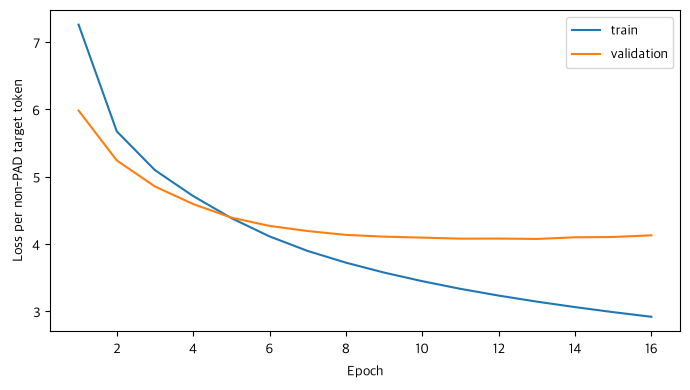

별도 test loss: 4.0472


,korean,reference,prediction,eos,no_repeat_ngram_size
0,우비넨은 이후 경찰 특수 기동대가 학교 안으로 침투했을 때 건물 로비에서 자신의 머...,when the police s special swat unit entered th...,auvinen then fired his head when he walked int...,True,3
1,리자 머피 레인포레스트 알리안스의 환경 보존 산림 프로그램 마케팅 담당자는 fsc의...,we applaud scholastic s progressive and bold c...,we welcome the decision to ban the use of toxi...,True,3
2,그는 그날 다른 두 명도 죽인 것으로 여겨진다 .,he is also thought to have killed two people e...,he also said two other people were killed .,True,3
3,도시의 거리를 따라 운전을 하다 보면 음식점이 댈러스 산업의 상당한 부분을 차지하고...,drive down any downtown street and it s clear ...,the street is driving the street street street...,True,3
4,만일 명이 선발되면 각각 만달러씩 나눠 지급받는다 .,"if only two ideas are chosen , each will recei...","if the winner was selected , the winner would ...",True,3


In [ ]:
if not BEST_PATH.exists():
    raise FileNotFoundError("best.pt가 없습니다. 최소 1 epoch를 완료한 뒤 평가하세요.")
best_state = torch.load(BEST_PATH, map_location="cpu", weights_only=True)
if best_state["signature"] != TRAIN_SIGNATURE:
    raise ValueError("best.pt의 설정이 현재 설정과 다릅니다. 올바른 RUN_NAME과 설정을 복원하세요.")
if "transformer" in globals():
    del transformer
best_model = Transformer(**MODEL_CONFIG).to(device)
best_model.load_state_dict(best_state["model"])
best_model.eval()
best_epoch = best_state["epoch"]
best_val_loss = best_state["val_loss"]
del best_state
print(f"선택 모델: epoch {best_epoch}, validation loss {best_val_loss:.4f}")

latest = torch.load(LATEST_PATH, map_location="cpu", weights_only=True)
history = pd.DataFrame(latest["progress"]["history"])
del latest
if not history.empty:
    display(history)
    plt.figure(figsize=(7, 4))
    plt.plot(history["epoch"], history["train_loss"], label="train")
    plt.plot(history["epoch"], history["val_loss"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss per non-PAD target token")
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULT_DIR / "loss_curve.png", dpi=140)
    plt.show()

test_loss = evaluate_loss(best_model, dataset["test"])
print("별도 test loss:", round(test_loss, 4))
test_rows = []
for ko, en in dataset["test"]["pairs"][:TEST_EXAMPLES]:
    result = evaluate(ko, best_model)
    test_rows.append({"korean": ko, "reference": en, "prediction": result["text"],
                      "eos": result["ended_with_eos"], "no_repeat_ngram_size": result["no_repeat_ngram_size"]})
test_table = pd.DataFrame(test_rows)
display(test_table)
test_table.to_csv(RESULT_DIR / "test_translations.csv", index=False, encoding="utf-8-sig")

## 10. 예문 4개·직접 입력한 문장 번역
아래 `MY_SENTENCES`에 문장을 추가할 수 있습니다. 과제 예문은 항상 별도로 출력·저장합니다.
**번역이 자연스러워 보여도 원문에 없는 정보가 붙었는지 확인**하세요. 예를 들어 '일곱 명이 사망했다'에 공격·지역·인물 정보를 임의로 추가했다면 오류입니다.

반복 제한 전후만 비교하려면 학습 완료 후 다음을 별도 셀에서 실행하세요. 같은 `best_model`로 비교하며 재학습은 필요하지 않습니다.
```python
sentence = "시민들은 도시 속에 산다."
for n in [0, 3]:
    result = evaluate(sentence, best_model, no_repeat_ngram_size=n)
    print(f"반복 제한 {n}: {result['text']} | EOS: {result['ended_with_eos']}")
```


In [ ]:
# ★ 이 목록에 직접 번역해 보고 싶은 한국어를 넣으세요.
MY_SENTENCES = ["나는 커피를 좋아한다."]

example_results, example_rows = [], []
for sentence in EXAMPLES:
    result = translate(sentence, best_model)
    example_results.append(result)
    example_rows.append({"korean": sentence, "prediction": result["text"],
                         "eos": result["ended_with_eos"], "no_repeat_ngram_size": result["no_repeat_ngram_size"], "meaning_review": "직접 평가"})
example_table = pd.DataFrame(example_rows)
display(example_table)
example_table.to_csv(RESULT_DIR / "rubric_examples.csv", index=False, encoding="utf-8-sig")
for sentence in MY_SENTENCES:
    translate(sentence, best_model)

한국어: 오바마는 대통령이다.
영어: obama is in office .
한국어: 시민들은 도시 속에 산다.
영어: people are in the city .
한국어: 커피는 필요 없다.
영어: coffee is necessary .
한국어: 일곱 명의 사망자가 발생했다.
영어: seven people were killed in the attack .


,korean,prediction,eos,no_repeat_ngram_size,meaning_review
0,오바마는 대통령이다.,obama is in office .,True,3,직접 평가
1,시민들은 도시 속에 산다.,people are in the city .,True,3,직접 평가
2,커피는 필요 없다.,coffee is necessary .,True,3,직접 평가
3,일곱 명의 사망자가 발생했다.,seven people were killed in the attack .,True,3,직접 평가


한국어: 나는 커피를 좋아한다.
영어: i like coffee .


## 11. Attention Map으로 결과 확인
**Cross-Attention:** 가로축은 한국어 Key, 세로축은 **그 행을 이용해 예측한 영어 토큰**입니다.  
BOS 입력 행은 첫 영어 토큰을 예측하므로, BOS 라벨을 첫 예측 단어로 착각하지 않게 생성 시점마다 마지막 query 행을 따로 모았습니다.

`ATTENTION_LAYER=-1`: 마지막 층. `ATTENTION_HEAD=None`: head 평균. 특정 head는 0~7로 바꿉니다.
평균은 서로 다른 head의 특징을 섞을 수 있습니다. 첫 단어가 반드시 흐릿하다거나 특정 층이 반드시 특정 역할을 한다고 단정하지 마세요.
`_`는 SentencePiece의 단어 경계 표식을 표시한 것이며 단어의 일부가 아닙니다.

**Decoder Self-Attention:** 두 축 모두 실제 디코더 **입력** 토큰입니다. 오른쪽 위가 0이면 미래 토큰이 가려진 것입니다.

예문 1: 오바마는 대통령이다. → obama is in office .


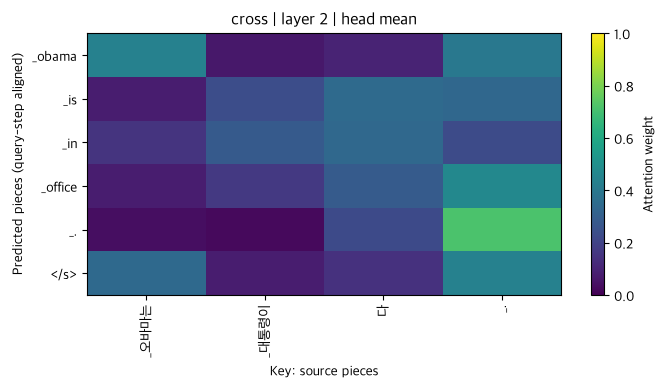

예문 2: 시민들은 도시 속에 산다. → people are in the city .


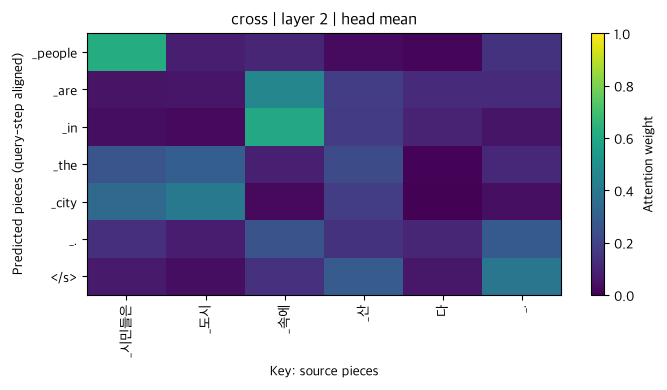

예문 3: 커피는 필요 없다. → coffee is necessary .


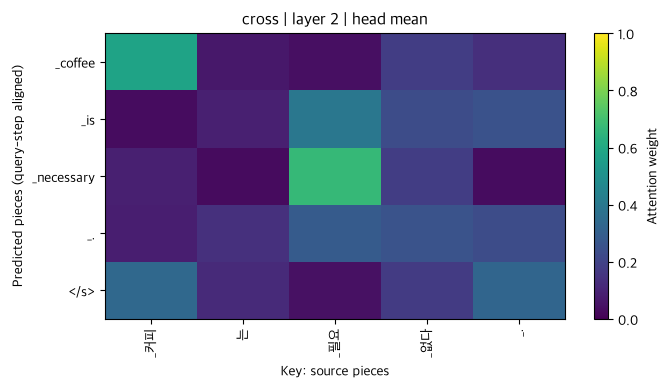

예문 4: 일곱 명의 사망자가 발생했다. → seven people were killed in the attack .


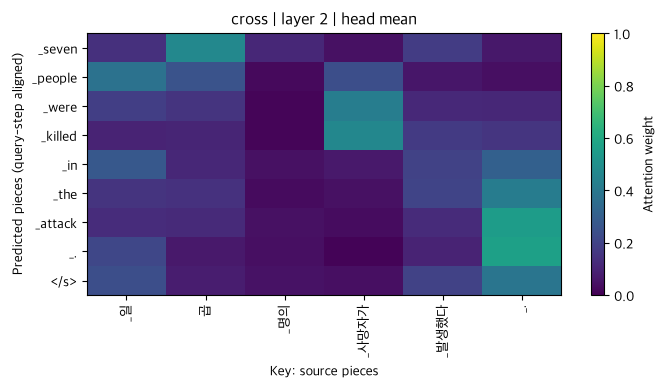

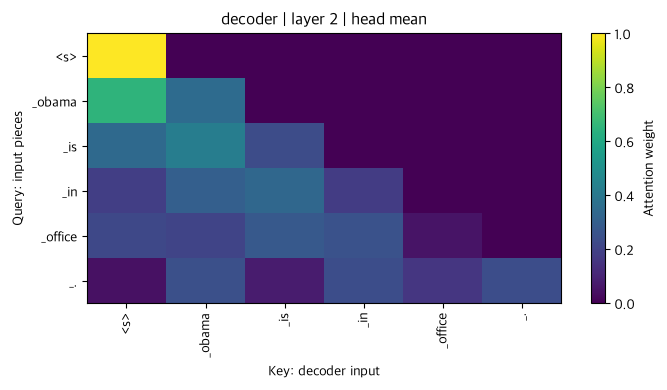

In [ ]:
def plot_attention_map(result, kind="cross", layer=-1, head=None, filename=None):
    weights = result[kind][layer]  # [heads, query_length, key_length]
    if head is not None and not 0 <= head < weights.size(0):
        raise ValueError(f"head는 0~{weights.size(0) - 1} 또는 None이어야 합니다.")
    matrix = weights.mean(dim=0) if head is None else weights[head]
    if kind == "cross":
        x_labels, y_labels = result["src_labels"], result["output_labels"]
    elif kind == "encoder":
        x_labels = y_labels = result["src_labels"]
    else:
        x_labels = y_labels = result["input_labels"]
    assert tuple(matrix.shape) == (len(y_labels), len(x_labels)), "축 라벨과 어텐션 위치가 다릅니다."
    figure, ax = plt.subplots(figsize=(max(7, len(x_labels) * 0.4), max(4, len(y_labels) * 0.3)))
    image = ax.imshow(matrix.numpy(), aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(x_labels)), x_labels, rotation=90)
    ax.set_yticks(range(len(y_labels)), y_labels)
    selected_layer = layer if layer >= 0 else len(result[kind]) + layer
    ax.set_title(f"{kind} | layer {selected_layer + 1} | head {head if head is not None else 'mean'}")
    ax.set_xlabel("Key: source pieces" if kind != "decoder" else "Key: decoder input")
    ax.set_ylabel("Predicted pieces (query-step aligned)" if kind == "cross" else "Query: input pieces")
    figure.colorbar(image, ax=ax, label="Attention weight")
    figure.tight_layout()
    if filename:
        figure.savefig(RESULT_DIR / filename, dpi=140)
    plt.show()
    plt.close(figure)

for index, result in enumerate(example_results, start=1):
    print(f"예문 {index}:", EXAMPLES[index - 1], "→", result["text"])
    plot_attention_map(result, "cross", ATTENTION_LAYER, ATTENTION_HEAD, f"attention_example_{index}.png")

# 첫 예문의 디코더 미래 마스크도 확인합니다.
plot_attention_map(example_results[0], "decoder", ATTENTION_LAYER, ATTENTION_HEAD, "decoder_causal_mask.png")

### 11-1. 16회차 기준 Attention Map(어텐션 맵)
`epoch_016.pt`를 별도 모델로 읽어 예문 4개를 다시 번역합니다. `best_model`과 학습용 모델은 그대로 둡니다.
Cross-Attention(교차 어텐션) 4개와 첫 예문의 Decoder Self-Attention(디코더 자기 어텐션)을 `results/epoch_016/`에 저장합니다.
마지막 층·head(헤드) 평균 등 기존 `ATTENTION_LAYER`, `ATTENTION_HEAD`, 생성 규칙을 그대로 사용합니다.

**실행 순서:** 7-3의 `preserve_epoch16()`와 11번의 `plot_attention_map()` 정의가 필요합니다. 추가 학습 전후 어느 때나 같은 16회차 가중치로 실행할 수 있습니다.
예문에서 번역이 좋아 보이는지와 전체 validation loss(검증 손실)는 함께 살펴보세요. 어텐션 값만으로 번역 정확성을 판정할 수는 없습니다.

Attention 기준: epoch 16 | val=4.1286
한국어: 오바마는 대통령이다.
영어: obama is the president .
한국어: 시민들은 도시 속에 산다.
영어: people are living in the cities .
한국어: 커피는 필요 없다.
영어: coffee is not necessary .
한국어: 일곱 명의 사망자가 발생했다.
영어: seven people were killed in the blast .


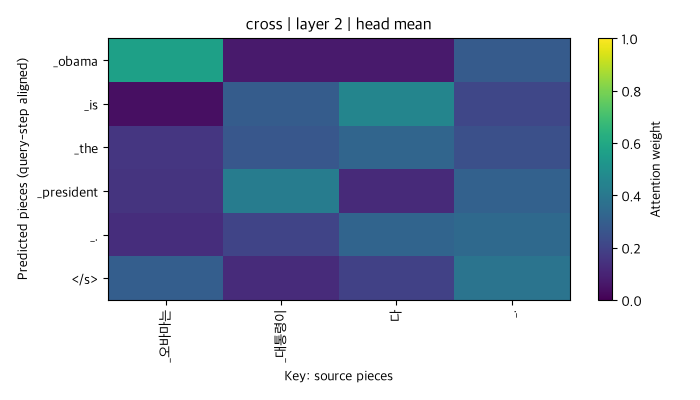

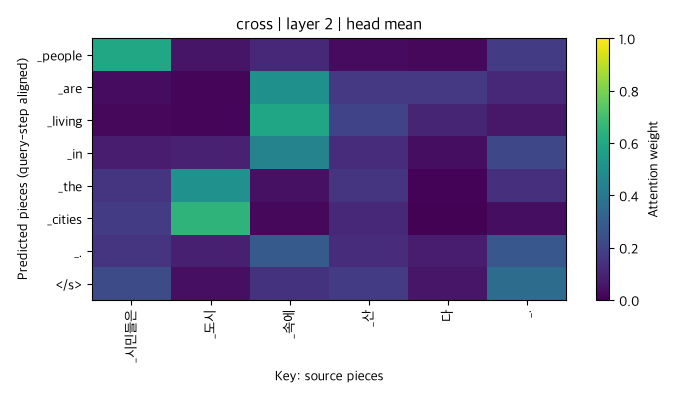

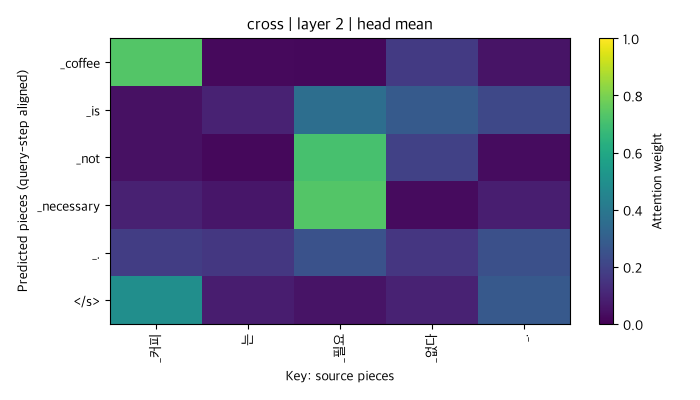

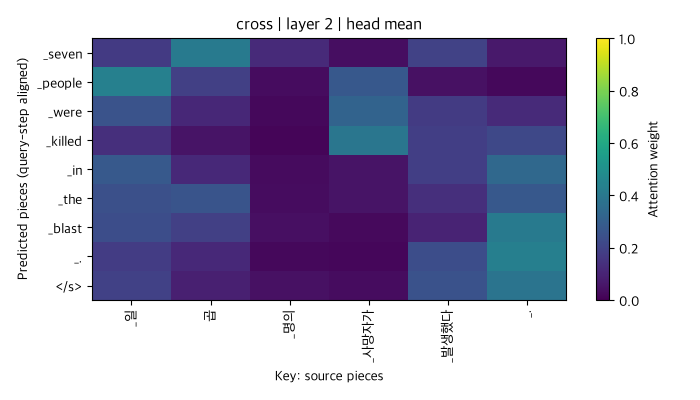

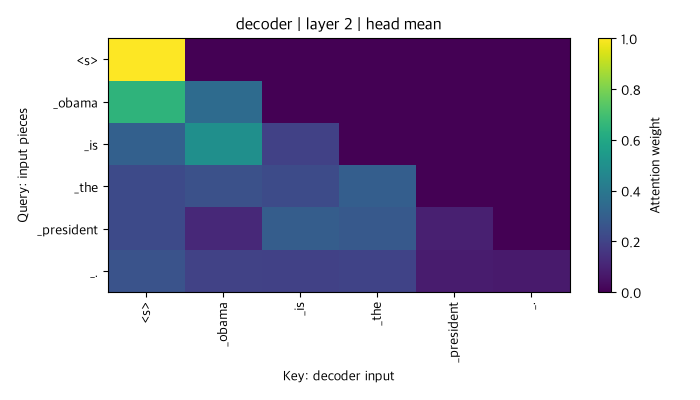

epoch,korean,prediction,eos,no_repeat_ngram_size
16,오바마는 대통령이다.,obama is the president .,True,3
16,시민들은 도시 속에 산다.,people are living in the cities .,True,3
16,커피는 필요 없다.,coffee is not necessary .,True,3
16,일곱 명의 사망자가 발생했다.,seven people were killed in the blast .,True,3


In [ ]:
epoch16_state = preserve_epoch16()
# 모델 생성이 이후 학습의 CPU 난수 상태를 바꾸지 않게 합니다.
with torch.random.fork_rng(devices=[]):
    epoch16_model = Transformer(**MODEL_CONFIG)
epoch16_model.load_state_dict(epoch16_state["model"])
epoch16_model.to(device).eval()
print(f"Attention 기준: epoch 16 | val={epoch16_state['val_loss']:.4f}")
del epoch16_state

epoch16_dir = RESULT_DIR / "epoch_016"
epoch16_dir.mkdir(parents=True, exist_ok=True)
epoch16_results, epoch16_rows = [], []
try:
    for index, sentence in enumerate(EXAMPLES, start=1):
        result = translate(sentence, epoch16_model)
        epoch16_results.append(result)
        epoch16_rows.append({"epoch": 16, "korean": sentence,
                             "prediction": result["text"], "eos": result["ended_with_eos"],
                             "no_repeat_ngram_size": result["no_repeat_ngram_size"]})
        plot_attention_map(result, "cross", ATTENTION_LAYER, ATTENTION_HEAD,
                           f"epoch_016/attention_example_{index}.png")
    plot_attention_map(epoch16_results[0], "decoder", ATTENTION_LAYER, ATTENTION_HEAD,
                       "epoch_016/decoder_causal_mask.png")
    epoch16_table = pd.DataFrame(epoch16_rows)
    display(epoch16_table)
    epoch16_table.to_csv(epoch16_dir / "translations.csv", index=False, encoding="utf-8-sig")
finally:
    del epoch16_model


## 14. 전체 학습에서 드러난 특성



** 핵심 내용에 익숙한 사건 정보를 덧붙이는 경향이 있었다.**  
사망자 예문은 ‘일곱 명’이라는 수를 맞춘 뒤에도 공격·폭발·병원 정보를 덧붙였다. 시민 예문도 ‘도시’라는 단어를 유지하면서 거주 의미를 빠뜨리거나 매장 사건으로 바꿨다. 핵심 단어를 포함하면서 문장 관계와 사건 내용을 잘못 완성하는 오류다. 뉴스 코퍼스로 학습한 모델이 입력에 없는 부분까지 뉴스에서 익숙한 표현으로 채우는 경향으로 해석할 수 있다.

** 후반 학습은 검증 성능보다 훈련 데이터에 더 잘 맞춰졌다.**  
13→26회차에서 train loss(학습 손실)는 `3.1434 → 2.4386`으로 줄었지만, validation loss(검증 손실)는 `4.0750 → 4.2789`로 매 회차 올랐다. 이는 overfitting(과적합) 양상이다. 그 사이 16·24회차에서 일부 예문이 좋아진 것은 특정 문장의 개선이며, 전체 검증 성능의 회복으로 이어지지는 않았다.

검증 손실이 가장 낮은 **13회차**와 예문이 자연스러웠던 **16회차**가 달랐던 점도 이 차이로 이해할 수 있다. 검증 손실은 정답 영어를 앞선 입력으로 주는 teacher forcing(정답을 입력으로 제공하는 방식)의 평균 점수다. 실제 번역에서는 모델이 앞서 생성한 토큰을 이어받으므로, 예문 4개의 결과와 평균 손실이 항상 같은 순서로 좋아지지는 않는다. 16회차 어텐션 맵에서 `coffee`가 ‘커피’를 강하게 참조한 것도 해당 토큰의 대응을 보여주며, 문장 전체의 정확성까지 보장하지는 않는다.



```Epoch 1/20: 100%|██████████| 1059/1059 [02:36<00:00,  6.75it/s, loss=7.2597]
오바마는 대통령이다. → the world s .
시민들은 도시 속에 산다. → the world s first time .
커피는 필요 없다. → the world s .
일곱 명의 사망자가 발생했다. → the u . s . s a u . were killed in the u , a u , and the u in the united states .
Epoch 1: train=7.2597, val=5.9825 | 저장 완료
Early stopping: 미개선 0/3회
Epoch 2/20: 100%|██████████| 1059/1059 [02:35<00:00,  6.80it/s, loss=5.6736]
오바마는 대통령이다. → obama s clinton s campaign , clinton s been a week .
시민들은 도시 속에 산다. → the city of the city s city of a .
커피는 필요 없다. → we are not be a lot of the same .
일곱 명의 사망자가 발생했다. → the two people were killed in the city of the city .
Epoch 2: train=5.6736, val=5.2416 | 저장 완료
Early stopping: 미개선 0/3회
Epoch 3/20: 100%|██████████| 1059/1059 [02:31<00:00,  6.97it/s, loss=5.0971]
오바마는 대통령이다. → obama s president , obama s a president .
시민들은 도시 속에 산다. → the city of the city s river .
커피는 필요 없다. → it s not not a lot .
일곱 명의 사망자가 발생했다. → the death toll , killed people .
Epoch 3: train=5.0971, val=4.8542 | 저장 완료
Early stopping: 미개선 0/3회
Epoch 4/20: 100%|██████████| 1059/1059 [02:32<00:00,  6.96it/s, loss=4.7124]
오바마는 대통령이다. → obama is a president elect to be president .
시민들은 도시 속에 산다. → the people are in the city of the city .
커피는 필요 없다. → there are no longer . . .
일곱 명의 사망자가 발생했다. → two people were killed in the capital .
Epoch 4: train=4.7124, val=4.5935 | 저장 완료
Early stopping: 미개선 0/3회
Epoch 5/20: 100%|██████████| 1059/1059 [02:31<00:00,  6.98it/s, loss=4.3846]
오바마는 대통령이다. → obama is in the president .
시민들은 도시 속에 산다. → the city of the city s capital , where the city is in the city .
커피는 필요 없다. → coffee is not a coffee .
일곱 명의 사망자가 발생했다. → the dead was killed in the city of ghazni province .
Epoch 5: train=4.3846, val=4.3922 | 저장 완료
Early stopping: 미개선 0/3회
Epoch 6/20: 100%|██████████| 1059/1059 [02:31<00:00,  7.00it/s, loss=4.1126]
오바마는 대통령이다. → obama is the president .
시민들은 도시 속에 산다. → many cities are in the city .
커피는 필요 없다. → coffee is not a coffee coffee .
일곱 명의 사망자가 발생했다. → the death toll from the city of columbia was killed .
Epoch 6: train=4.1126, val=4.2688 | 저장 완료
Early stopping: 미개선 0/3회
Epoch 7/20: 100%|██████████| 1059/1059 [02:31<00:00,  6.98it/s, loss=3.8963]
오바마는 대통령이다. → obama is the president .
시민들은 도시 속에 산다. → people living in the city .
커피는 필요 없다. → coffee is not easy to be coffee .
일곱 명의 사망자가 발생했다. → the dead were killed in the day .
Epoch 7: train=3.8963, val=4.1923 | 저장 완료
Early stopping: 미개선 0/3회
Epoch 8/20: 100%|██████████| 1059/1059 [02:32<00:00,  6.96it/s, loss=3.7227]
오바마는 대통령이다. → obama is in a speech .
시민들은 도시 속에 산다. → people are living in cities .
커피는 필요 없다. → coffee is not a coffee .
일곱 명의 사망자가 발생했다. → five people were killed in the sunday .
Epoch 8: train=3.7227, val=4.1352 | 저장 완료
Early stopping: 미개선 0/3회
Epoch 9/20: 100%|██████████| 1059/1059 [02:30<00:00,  7.04it/s, loss=3.5751]
오바마는 대통령이다. → obama is the president .
시민들은 도시 속에 산다. → people in the city of san jose , they were in the cities .
커피는 필요 없다. → coffee doesn t need a coffee .
일곱 명의 사망자가 발생했다. → five people were killed .
Epoch 9: train=3.5751, val=4.1090 | 저장 완료
Early stopping: 미개선 0/3회
Epoch 10/20: 100%|██████████| 1059/1059 [02:29<00:00,  7.10it/s, loss=3.4473]
오바마는 대통령이다. → obama is the president .
시민들은 도시 속에 산다. → people in the city of wen s .
커피는 필요 없다. → coffee is not necessary .
일곱 명의 사망자가 발생했다. → the seven died in the city .
Epoch 10: train=3.4473, val=4.0945 | 저장 완료
Early stopping: 미개선 0/3회
Epoch 11/20: 100%|██████████| 1059/1059 [02:30<00:00,  7.02it/s, loss=3.3333]
오바마는 대통령이다. → obama is the president .
시민들은 도시 속에 산다. → people are in the city .
커피는 필요 없다. → coffee is not necessary .
일곱 명의 사망자가 발생했다. → seven deaths were killed in the attack .
Epoch 11: train=3.3333, val=4.0792 | 저장 완료
Early stopping: 미개선 0/3회
Epoch 12/20: 100%|██████████| 1059/1059 [02:28<00:00,  7.11it/s, loss=3.2333]
오바마는 대통령이다. → obama is expected to be president .
시민들은 도시 속에 산다. → people in the city .
커피는 필요 없다. → coffee is not necessary .
일곱 명의 사망자가 발생했다. → seven people were killed .
Epoch 12: train=3.2333, val=4.0804 | 저장 완료
Early stopping: 미개선 1/3회
Epoch 13/20: 100%|██████████| 1059/1059 [02:28<00:00,  7.11it/s, loss=3.1434]
오바마는 대통령이다. → obama is in office .
시민들은 도시 속에 산다. → people are in the city .
커피는 필요 없다. → coffee is necessary .
일곱 명의 사망자가 발생했다. → seven people were killed in the attack .
Epoch 13: train=3.1434, val=4.0750 | 저장 완료
Early stopping: 미개선 0/3회
Epoch 14/20: 100%|██████████| 1059/1059 [02:29<00:00,  7.08it/s, loss=3.0620]
오바마는 대통령이다. → obama is the president .
시민들은 도시 속에 산다. → people are living in the city .
커피는 필요 없다. → coffee is not a coffee .
일곱 명의 사망자가 발생했다. → seven people were killed .
Epoch 14: train=3.0620, val=4.0991 | 저장 완료
Early stopping: 미개선 1/3회
Epoch 15/20: 100%|██████████| 1059/1059 [02:27<00:00,  7.19it/s, loss=2.9871]
오바마는 대통령이다. → obama is a president .
시민들은 도시 속에 산다. → people in the city .
커피는 필요 없다. → coffee is not a coffee .
일곱 명의 사망자가 발생했다. → seven people were killed in the blast .
Epoch 15: train=2.9871, val=4.1039 | 저장 완료
Early stopping: 미개선 2/3회
Epoch 16/20: 100%|██████████| 1059/1059 [02:27<00:00,  7.19it/s, loss=2.9182]
오바마는 대통령이다. → obama is the president .
시민들은 도시 속에 산다. → people are living in the cities .
커피는 필요 없다. → coffee is not necessary .
일곱 명의 사망자가 발생했다. → seven people were killed in the blast .
Epoch 16: train=2.9182, val=4.1286 | 저장 완료
Early stopping: 미개선 3/3회
조기 종료합니다. 최종 번역은 9번 평가 셀부터 실행하세요.```